In [1]:
import pandas as pd

tmp = pd.read_csv("../data/processed/y_train_risk.csv", header=None)
print(tmp.shape)
print(tmp.head(10))
print(tmp.tail(10))


(4001, 2)
        0       1
0     NaN  y_risk
1  4120.0       2
2  4121.0       2
3  4122.0       2
4  4123.0       2
5  4124.0       2
6  4125.0       2
7  4126.0       2
8  4127.0       2
9  4128.0       2
           0  1
3991  1788.0  0
3992  1789.0  0
3993  1790.0  0
3994  1791.0  0
3995  1792.0  0
3996  1793.0  0
3997  1794.0  0
3998  1795.0  0
3999  1796.0  0
4000  1797.0  0


In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, XGBRegressor


# =====================================================
# 1) LOAD DATA
# =====================================================
X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test  = pd.read_parquet("../data/processed/X_test.parquet")


def load_label_csv(path: str) -> pd.Series:
    df = pd.read_csv(path, header=None)
    if df.shape[1] >= 2:
        s = df.iloc[:, 1]
    else:
        s = df.iloc[:, 0]
    s = pd.to_numeric(s, errors="coerce")
    return s


y_train_risk = load_label_csv("../data/processed/y_train_risk.csv")
y_test_risk  = load_label_csv("../data/processed/y_test_risk.csv")

y_train_fatigue = load_label_csv("../data/processed/y_train_fatigue.csv")
y_test_fatigue  = load_label_csv("../data/processed/y_test_fatigue.csv")


# =====================================================
# 2) CLEAN / ALIGN
# =====================================================
y_train_risk = y_train_risk.iloc[:len(X_train)]
y_train_fatigue = y_train_fatigue.iloc[:len(X_train)]
y_test_risk = y_test_risk.iloc[:len(X_test)]
y_test_fatigue = y_test_fatigue.iloc[:len(X_test)]

train_mask = y_train_risk.notna()
test_mask = y_test_risk.notna()

X_train = X_train.loc[train_mask.values].copy()
y_train_risk = y_train_risk.loc[train_mask.values].astype(int)
y_train_fatigue = y_train_fatigue.loc[train_mask.values].astype(float)

X_test = X_test.loc[test_mask.values].copy()
y_test_risk = y_test_risk.loc[test_mask.values].astype(int)
y_test_fatigue = y_test_fatigue.loc[test_mask.values].astype(float)

feature_cols = list(X_train.columns)
label_classes = ["Low", "Medium", "High"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTrain class distribution:")
print(y_train_risk.value_counts(normalize=True).sort_index())
print("\nTest class distribution:")
print(y_test_risk.value_counts(normalize=True).sort_index())


# =====================================================
# 3) DEFINE CLASSIFIER CANDIDATES
# =====================================================
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_risk)

clf_candidates = {
    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500))
    ]),

    "RandomForestClassifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]),

    "XGBClassifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=250,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=3,
            reg_alpha=0.2,
            reg_lambda=2.0,
            gamma=0.1,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42
        ))
    ])
}


# =====================================================
# 4) TRAIN + EVALUATE CLASSIFIERS
# =====================================================
clf_results = []
trained_clfs = {}

for name, model in clf_candidates.items():
    print(f"\n==============================")
    print(f"Training classifier: {name}")

    if name == "XGBClassifier":
        model.fit(X_train, y_train_risk, model__sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train_risk)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test_risk, pred)
    macro_f1 = f1_score(y_test_risk, pred, average="macro")
    auc_ovr = roc_auc_score(y_test_risk, proba, multi_class="ovr")

    clf_results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "ROC-AUC OvR": auc_ovr
    })

    trained_clfs[name] = model

    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("ROC-AUC OvR:", auc_ovr)
    print("Confusion Matrix:\n", confusion_matrix(y_test_risk, pred))
    print("Classification Report:\n", classification_report(y_test_risk, pred, zero_division=0))

clf_results_df = pd.DataFrame(clf_results).sort_values(
    by=["Macro F1", "Accuracy", "ROC-AUC OvR"], ascending=False
).reset_index(drop=True)

print("\n=== CLASSIFIER COMPARISON ===")
print(clf_results_df)


# =====================================================
# 5) DEFINE REGRESSOR CANDIDATES
# =====================================================
reg_candidates = {
    "RandomForestRegressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBRegressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=3,
            reg_alpha=0.1,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=42
        ))
    ]),

    "LinearRegressionProxy": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500))
    ])
}

X_train: (3999, 12)
X_test : (999, 12)

Train class distribution:
1
0    0.398350
1    0.330833
2    0.270818
Name: proportion, dtype: float64

Test class distribution:
1
0    0.398398
1    0.322322
2    0.279279
Name: proportion, dtype: float64

Training classifier: LogisticRegression
Accuracy: 0.6896896896896897
Macro F1: 0.6855407378870382
ROC-AUC OvR: 0.8298812529346478
Confusion Matrix:
 [[331  62   5]
 [126 172  24]
 [ 26  67 186]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.83      0.75       398
           1       0.57      0.53      0.55       322
           2       0.87      0.67      0.75       279

    accuracy                           0.69       999
   macro avg       0.71      0.68      0.69       999
weighted avg       0.70      0.69      0.69       999


Training classifier: RandomForestClassifier
Accuracy: 0.7097097097097097
Macro F1: 0.7085290011484392
ROC-AUC OvR: 0.8775793407676581
Confusion Matrix:


In [13]:
from sklearn.linear_model import Ridge

reg_candidates = {
    "RandomForestRegressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBRegressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=3,
            reg_alpha=0.1,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=42
        ))
    ]),

    "RidgeRegressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
}


# =====================================================
# 6) TRAIN + EVALUATE REGRESSORS
# =====================================================
reg_results = []
trained_regs = {}

for name, model in reg_candidates.items():
    print(f"\n==============================")
    print(f"Training regressor: {name}")

    model.fit(X_train, y_train_fatigue)
    pred_f = model.predict(X_test)

    mae = mean_absolute_error(y_test_fatigue, pred_f)
    rmse = np.sqrt(mean_squared_error(y_test_fatigue, pred_f))
    r2 = r2_score(y_test_fatigue, pred_f)

    reg_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_regs[name] = model

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

reg_results_df = pd.DataFrame(reg_results).sort_values(
    by=["R2", "RMSE", "MAE"], ascending=[False, True, True]
).reset_index(drop=True)

print("\n=== REGRESSOR COMPARISON ===")
print(reg_results_df)


# =====================================================
# 7) RULE BASELINE COMPARISON
# =====================================================
def fatigue_to_risk(f):
    if f < 35:
        return 0
    elif f < 65:
        return 1
    else:
        return 2

best_clf_name = clf_results_df.iloc[0]["Model"]
best_clf = trained_clfs[best_clf_name]

best_pred = best_clf.predict(X_test)

baseline_pred = np.array([fatigue_to_risk(f) for f in y_test_fatigue])

benchmark_df = pd.DataFrame([
    {
        "Model": "Rule-only baseline (fatigue thresholds)",
        "Accuracy": accuracy_score(y_test_risk, baseline_pred),
        "Macro F1": f1_score(y_test_risk, baseline_pred, average="macro")
    },
    {
        "Model": best_clf_name,
        "Accuracy": accuracy_score(y_test_risk, best_pred),
        "Macro F1": f1_score(y_test_risk, best_pred, average="macro")
    }
])

print("\n=== BENCHMARK COMPARISON ===")
print(benchmark_df)


# =====================================================
# 8) SELECT BEST MODELS
# =====================================================
best_reg_name = reg_results_df.iloc[0]["Model"]
best_reg = trained_regs[best_reg_name]

print("\n=== FINAL SELECTED MODELS ===")
print("Best classifier:", best_clf_name)
print("Best regressor :", best_reg_name)


# =====================================================
# 9) SAVE FINAL SELECTED MODELS
# =====================================================
OUT = Path("../model_store")
OUT.mkdir(parents=True, exist_ok=True)

joblib.dump(best_clf, OUT / "risk_model.pkl")
joblib.dump(best_reg, OUT / "fatigue_model.pkl")
joblib.dump(feature_cols, OUT / "feature_cols.pkl")
joblib.dump(label_classes, OUT / "risk_label_classes.pkl")

print("\nSaved final selected models to model_store/")
print("Saved files:", [p.name for p in OUT.glob("*.pkl")])


Training regressor: RandomForestRegressor
MAE: 5.793432763522239
RMSE: 7.416099112616948
R2: 0.4834541672113831

Training regressor: XGBRegressor
MAE: 5.700618129132646
RMSE: 7.397686862014307
R2: 0.48601588187770695

Training regressor: RidgeRegressor
MAE: 6.377143620802351
RMSE: 8.384006444048943
R2: 0.33982204431406504

=== REGRESSOR COMPARISON ===
                   Model       MAE      RMSE        R2
0           XGBRegressor  5.700618  7.397687  0.486016
1  RandomForestRegressor  5.793433  7.416099  0.483454
2         RidgeRegressor  6.377144  8.384006  0.339822

=== BENCHMARK COMPARISON ===
                                     Model  Accuracy  Macro F1
0  Rule-only baseline (fatigue thresholds)  0.421421  0.252624
1                            XGBClassifier  0.734735  0.737997

=== FINAL SELECTED MODELS ===
Best classifier: XGBClassifier
Best regressor : XGBRegressor

Saved final selected models to model_store/
Saved files: ['fatigue_model.pkl', 'feature_cols.pkl', 'risk_label_cl

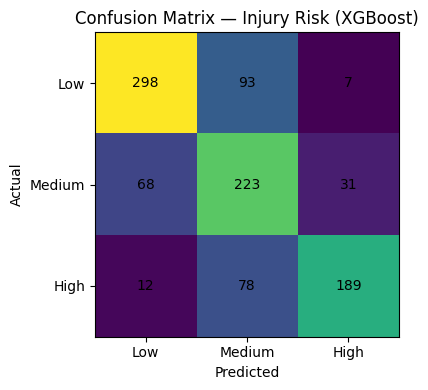

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_risk, pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix — Injury Risk (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1,2], ["Low","Medium","High"])
plt.yticks([0,1,2], ["Low","Medium","High"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [4]:
from sklearn.metrics import classification_report
import pandas as pd

rep = classification_report(
    y_test_risk, pred,
    target_names=["Low","Medium","High"],
    output_dict=True
)
rep_df = pd.DataFrame(rep).T
rep_df

,precision,recall,f1-score,support
Low,0.788360,0.748744,0.768041,398.000000
Medium,0.565990,0.692547,0.622905,322.000000
High,0.832599,0.677419,0.747036,279.000000
accuracy,0.710711,0.710711,0.710711,0.710711
macro avg,0.728983,0.706237,0.712661,999.000000
weighted avg,0.729040,0.710711,0.715394,999.000000


In [5]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test_risk, proba, multi_class="ovr")
roc_auc

0.8727811530266626

In [6]:
import pandas as pd

metrics_df = pd.DataFrame([{
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}])
metrics_df

,MAE,RMSE,R2
0,5.917943,7.704508,0.442496


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score

def fatigue_to_risk(f):
    if f < 35:
        return 0
    elif f < 65:
        return 1
    else:
        return 2

baseline_pred = np.array([fatigue_to_risk(f) for f in y_test_fatigue])

baseline_acc = accuracy_score(y_test_risk, baseline_pred)
baseline_f1  = f1_score(y_test_risk, baseline_pred, average="macro")

ml_acc = accuracy_score(y_test_risk, pred)
ml_f1  = f1_score(y_test_risk, pred, average="macro")

import pandas as pd
pd.DataFrame([
  {"Model": "Rule-only baseline (fatigue thresholds)", "Accuracy": baseline_acc, "Macro F1": baseline_f1},
  {"Model": "XGBoost classifier (final)", "Accuracy": ml_acc, "Macro F1": ml_f1}
])

,Model,Accuracy,Macro F1
0,Rule-only baseline (fatigue thresholds),0.421421,0.252624
1,XGBoost classifier (final),0.710711,0.712661


In [8]:
import time
start = time.time()
risk_model.predict(X_test.iloc[:1])
elapsed = time.time() - start
elapsed

0.007001638412475586

In [14]:
best_clf = joblib.load("../model_store/risk_model.pkl")
best_reg = joblib.load("../model_store/fatigue_model.pkl")
feature_cols = joblib.load("../model_store/feature_cols.pkl")
label_classes = joblib.load("../model_store/risk_label_classes.pkl")

test_rows = pd.DataFrame([
    {
        "deliveries_match": 72,
        "deliveries_7d": 240,
        "deliveries_28d": 700,
        "acwr_std": 1.37,
        "days_since_prev": 1,
        "match_day": 3,
        "avg_temp_c": 31,
        "avg_humidity_pct": 78,
        "precip_mm": 3,
        "esi_norm": 0.65,
        "age_years": 28,
        "inferred_fielding_time_minutes": 160
    },
    {
        "deliveries_match": 108,
        "deliveries_7d": 340,
        "deliveries_28d": 1100,
        "acwr_std": 1.32,
        "days_since_prev": 2,
        "match_day": 3,
        "avg_temp_c": 31,
        "avg_humidity_pct": 79,
        "precip_mm": 3,
        "esi_norm": 0.66,
        "age_years": 29,
        "inferred_fielding_time_minutes": 260
    },
    {
        "deliveries_match": 156,
        "deliveries_7d": 520,
        "deliveries_28d": 1350,
        "acwr_std": 1.85,
        "days_since_prev": 0,
        "match_day": 4,
        "avg_temp_c": 34,
        "avg_humidity_pct": 88,
        "precip_mm": 6,
        "esi_norm": 0.90,
        "age_years": 31,
        "inferred_fielding_time_minutes": 360
    }
])[feature_cols]

pred_test = best_clf.predict(test_rows)
proba_test = best_clf.predict_proba(test_rows)
fatigue_test = best_reg.predict(test_rows)

for i in range(len(test_rows)):
    print(f"\nScenario {i+1}")
    print("Predicted class index:", pred_test[i])
    print("Predicted label:", label_classes[int(pred_test[i])] if isinstance(pred_test[i], (int, float, np.integer)) else pred_test[i])
    print("Probabilities:", proba_test[i])
    print("Fatigue score:", fatigue_test[i])


Scenario 1
Predicted class index: 1
Predicted label: Medium
Probabilities: [0.21262664 0.7033498  0.08402355]
Fatigue score: 27.653835

Scenario 2
Predicted class index: 1
Predicted label: Medium
Probabilities: [0.23995794 0.6541775  0.10586462]
Fatigue score: 25.536322

Scenario 3
Predicted class index: 1
Predicted label: Medium
Probabilities: [0.03823143 0.69744194 0.26432657]
Fatigue score: 27.88443
